In [41]:
import pandas as pd

df = pd.read_csv("full_df.csv")
df.isnull().sum()

ID                           0
Patient Age                  0
Patient Sex                  0
Left-Fundus                  0
Right-Fundus                 0
Left-Diagnostic Keywords     0
Right-Diagnostic Keywords    0
N                            0
D                            0
G                            0
C                            0
A                            0
H                            0
M                            0
O                            0
filepath                     0
labels                       0
target                       0
filename                     0
dtype: int64

In [42]:
print(df.duplicated().sum())

0


In [43]:
print(df['labels'].value_counts())

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64


In [44]:
print(df[['filename','filepath']].head())

      filename                                           filepath
0  0_right.jpg  ../input/ocular-disease-recognition-odir5k/ODI...
1  1_right.jpg  ../input/ocular-disease-recognition-odir5k/ODI...
2  2_right.jpg  ../input/ocular-disease-recognition-odir5k/ODI...
3  4_right.jpg  ../input/ocular-disease-recognition-odir5k/ODI...
4  5_right.jpg  ../input/ocular-disease-recognition-odir5k/ODI...


In [45]:
import os

df['new_path'] = df['filename'].apply(
    lambda x: os.path.join('preprocessed_images', x)
)

print(df['new_path'].head())

0    preprocessed_images\0_right.jpg
1    preprocessed_images\1_right.jpg
2    preprocessed_images\2_right.jpg
3    preprocessed_images\4_right.jpg
4    preprocessed_images\5_right.jpg
Name: new_path, dtype: object


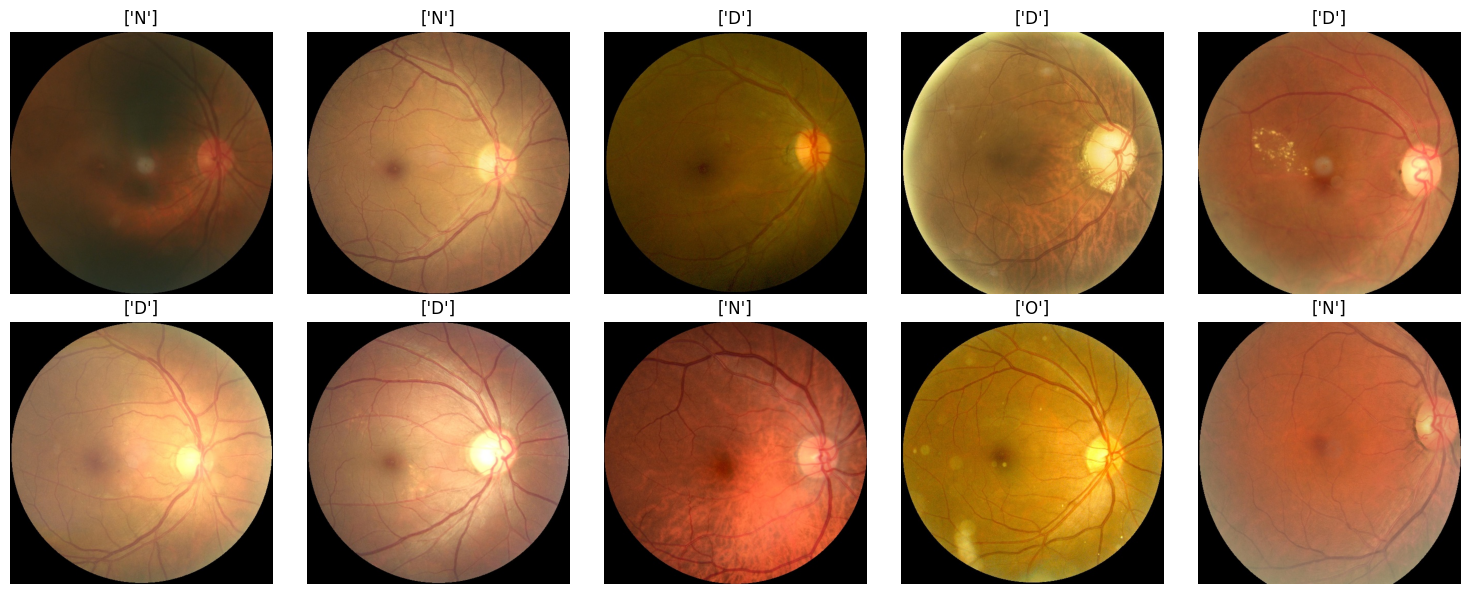

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(15,6))

for i, ax in enumerate(axes.flat):
    img = Image.open(df.iloc[i]['new_path'])
    ax.imshow(img)
    ax.set_title(df.iloc[i]['labels'])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [47]:
# label encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['encoded_labels'] = le.fit_transform(df['labels'])
print(df[['labels','encoded_labels']].head())

print(dict(zip(le.classes_, le.transform(le.classes_))))

  labels  encoded_labels
0  ['N']               6
1  ['N']               6
2  ['D']               2
3  ['D']               2
4  ['D']               2
{"['A']": 0, "['C']": 1, "['D']": 2, "['G']": 3, "['H']": 4, "['M']": 5, "['N']": 6, "['O']": 7}


In [48]:
print(df.shape)
print(df.head())

(6392, 21)
   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   4           53        Male  4_left.jpg  4_right.jpg   
4   5           50      Female  5_left.jpg  5_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                        macular epiretinal membrane   
4             moderate non proliferative retinopathy   

                Right-Diagnostic Keywords  N  D  G  ...  A  H  M  O  \
0                           normal fundus  0  0  0  ...  0  0  0  0   
1                           normal fundus  1  0  0  ...  0  0  0  0   
2  moderate non proliferative retinopathy  0  1  0  ...  0  0  0  1   
3       mild 

In [49]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['labels'],
    random_state=42
)

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df['encoded_label'] = le.fit_transform(train_df['labels'])
test_df['encoded_label'] = le.transform(test_df['labels'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{"['A']": 0, "['C']": 1, "['D']": 2, "['G']": 3, "['H']": 4, "['M']": 5, "['N']": 6, "['O']": 7}


In [51]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class EyeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'new_path']
        image = Image.open(img_path).convert('RGB')

        label = torch.tensor(
            self.df.loc[idx, 'encoded_label'],
            dtype=torch.long
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [53]:
from torch.utils.data import DataLoader

train_dataset = EyeDataset(train_df, train_transform)
test_dataset = EyeDataset(test_df, test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [54]:
torch.cuda.is_available()

True

In [55]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [56]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [57]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights='DEFAULT')

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 8)   # 8 classes

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [58]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [59]:
import torch

num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Train Accuracy: {train_acc:.2f}%")

Epoch [1/10] Loss: 1.3094 Train Accuracy: 52.77%
Epoch [2/10] Loss: 0.9949 Train Accuracy: 62.33%
Epoch [3/10] Loss: 0.8419 Train Accuracy: 68.84%
Epoch [4/10] Loss: 0.7022 Train Accuracy: 73.44%
Epoch [5/10] Loss: 0.6000 Train Accuracy: 77.63%
Epoch [6/10] Loss: 0.5009 Train Accuracy: 81.58%
Epoch [7/10] Loss: 0.4080 Train Accuracy: 85.49%
Epoch [8/10] Loss: 0.3327 Train Accuracy: 88.03%
Epoch [9/10] Loss: 0.2911 Train Accuracy: 89.52%
Epoch [10/10] Loss: 0.2315 Train Accuracy: 91.71%


In [60]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 66.85%


In [61]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.71      0.57      0.63        53
           1       0.90      0.78      0.84        59
           2       0.66      0.55      0.60       322
           3       0.43      0.40      0.41        57
           4       0.29      0.08      0.12        25
           5       0.87      0.89      0.88        46
           6       0.69      0.82      0.75       575
           7       0.51      0.44      0.47       142

    accuracy                           0.67      1279
   macro avg       0.63      0.57      0.59      1279
weighted avg       0.66      0.67      0.66      1279



In [62]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['encoded_label']),
    y=train_df['encoded_label']
)

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

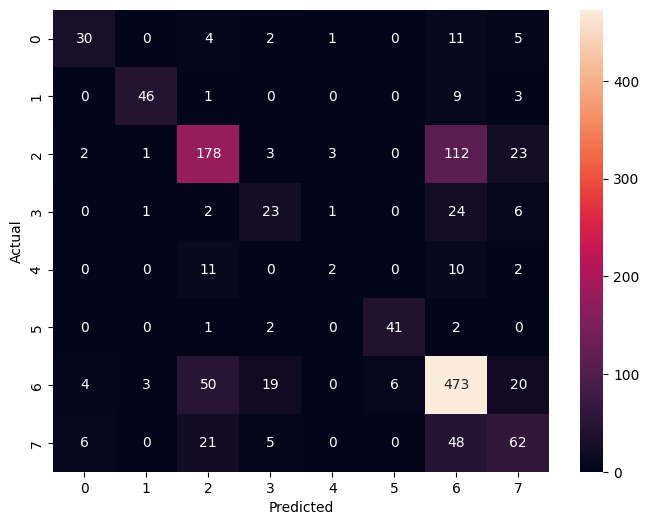

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()